# 🗳️ Notebook 3 — PhishVote: Our Proposed Model

## Output format
Matches Saeed (2025) exactly for paper comparability:
1. **Confusion Matrix** per model (same heatmap style)
2. **Classification Report** per model (precision, recall, f1-score, support + accuracy + macro/weighted avg)
3. **Accuracy Table** — mirrors their Table I

## PhishVote methodology
- **Deduplication** before split (eliminates test leakage)
- **StandardScaler** (same as baseline)
- **SMOTE** applied if class imbalance ratio < 0.80
- **80/20 stratified split** (stratify=y ensures balanced test classes)
- **Base models**: Random Forest, XGBoost, CatBoost, LightGBM, Gradient Boosting
- **Ensemble**: Adaptive Soft Voting with rank-based weights (models ranked by CV-AUC; weights used internally only, not reported as a metric)

## Datasets
- **DS-Baseline** (`phishing-2020.csv`) — deduped, same data as Saeed (2025)
- **DS01** (`LegitPhish2025.csv`) — our novel 2025 dataset

In [1]:
# ==========================================
# 1. SETUP
# ==========================================
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost catboost lightgbm imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})
SEED = 42
print('✅ Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00
✅ Setup complete.


In [2]:
# ==========================================
# 2. LOAD & DEDUPLICATE DATASETS
# ==========================================

# --- DS-Baseline ---
df_base = pd.read_csv('phishing-2020.csv')
df_base = df_base.drop(columns=['Index'], errors='ignore')
df_base['label'] = df_base['class'].map({1: 1, -1: 0})
df_base = df_base.drop(columns=['class'])
assert df_base['label'].isnull().sum() == 0

# --- DS01 ---
df_ds01 = pd.read_csv('LegitPhish2025.csv')
df_ds01['label'] = df_ds01['ClassLabel'].map({0: 1, 1: 0})
df_ds01 = df_ds01.drop(columns=['ClassLabel', 'URL'], errors='ignore')
for col in df_ds01.columns:
    if col != 'label' and df_ds01[col].dtype == 'object':
        df_ds01[col] = pd.to_numeric(df_ds01[col], errors='coerce')
df_ds01 = df_ds01.fillna(0)
assert df_ds01['label'].isnull().sum() == 0

# Deduplicate (our standard — eliminates test leakage)
df_base_d = df_base.drop_duplicates().reset_index(drop=True)
df_ds01_d = df_ds01.drop_duplicates().reset_index(drop=True)

print('DS-Baseline after dedup:', df_base_d.shape,
      f'  (removed {len(df_base)-len(df_base_d):,} duplicates)')
print('DS01 after dedup:        ', df_ds01_d.shape,
      f'  (removed {len(df_ds01)-len(df_ds01_d):,} duplicates)')

DS-Baseline after dedup: (5849, 31)   (removed 5,205 duplicates)
DS01 after dedup:         (31808, 17)   (removed 69,411 duplicates)


In [3]:
# ==========================================
# 3. UTILITY FUNCTIONS
# ==========================================

def plot_confusion_matrix(y_true, y_pred, model_name, dataset_label, ax):
    """Same style as Saeed (2025): raw counts, True Labels y-axis, Predicted x-axis."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=[0, 1], yticklabels=[0, 1],
        linewidths=0.5, linecolor='white', cbar=True,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_xlabel('Predicted Labels', fontsize=11)
    ax.set_ylabel('True Labels', fontsize=11)
    ax.set_title(f'Confusion Matrix\n{model_name}\n({dataset_label})', fontweight='bold')


def print_classification_report(y_true, y_pred, model_name, dataset_label):
    print(f'\n--- {model_name} | {dataset_label} ---')
    print(classification_report(
        y_true, y_pred,
        target_names=['0 (legitimate)', '1 (phishing)'],
        digits=2
    ))


def get_metrics(y_true, y_pred, model_name):
    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
    }


def adaptive_soft_vote(probs_dict, weights_dict):
    """
    Weighted average of predicted probabilities.
    weights_dict: {model_name: weight} — derived from CV-AUC rank.
    Returns hard predictions (threshold 0.5) and the weighted probability array.
    """
    total_w = sum(weights_dict.values())
    weighted = sum(
        probs_dict[name] * (w / total_w)
        for name, w in weights_dict.items()
    )
    return (weighted[:, 1] >= 0.5).astype(int)


print('✅ Utilities ready.')

✅ Utilities ready.


In [4]:
# ==========================================
# 4. PHISHVOTE PIPELINE FUNCTION
# ==========================================

def run_phishvote(df_clean, dataset_label):
    print(f'\n{"="*60}')
    print(f'  PhishVote — {dataset_label}')
    print(f'{"="*60}')
    print(f'  Rows (deduped): {len(df_clean):,}  |  '
          f'Legitimate (0): {(df_clean.label==0).sum():,}  |  '
          f'Phishing (1): {(df_clean.label==1).sum():,}')

    X = df_clean.drop(columns=['label'])
    y = df_clean['label']

    # Stratified 80/20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')
    print(f'  Test class 0: {(y_test==0).sum():,}  |  Test class 1: {(y_test==1).sum():,}')

    # StandardScaler
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # SMOTE if imbalanced
    ratio = y_train.value_counts().min() / y_train.value_counts().max()
    if ratio < 0.80:
        sm = SMOTE(random_state=SEED)
        X_train_s, y_train = sm.fit_resample(X_train_s, y_train)
        print(f'  SMOTE applied (imbalance={ratio:.2f}) → train: {len(y_train):,} rows')
    else:
        print(f'  SMOTE skipped (ratio={ratio:.2f} — balanced)')

    # Base models
    base_models = {
        'Random Forest':     RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
        'XGBoost':           XGBClassifier(n_estimators=200, eval_metric='logloss',
                                           random_state=SEED, verbosity=0),
        'CatBoost':          CatBoostClassifier(iterations=200, verbose=0, random_state=SEED),
        'LightGBM':          LGBMClassifier(n_estimators=200, random_state=SEED, verbose=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    }

    cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_aucs  = {}
    probs    = {}
    results  = []
    trained  = {}

    for name, model in base_models.items():
        # CV-AUC used internally for rank weighting only
        auc = cross_val_score(model, X_train_s, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1).mean()
        cv_aucs[name] = auc

        model.fit(X_train_s, y_train)
        trained[name] = model
        pred          = model.predict(X_test_s)
        probs[name]   = model.predict_proba(X_test_s)
        results.append(get_metrics(y_test, pred, name))

    # Rank-based weights (highest CV-AUC = highest weight)
    ranked   = sorted(cv_aucs.items(), key=lambda x: x[1], reverse=True)
    n        = len(ranked)
    weights  = {name: n - i for i, (name, _) in enumerate(ranked)}

    # Adaptive soft vote
    ens_pred = adaptive_soft_vote(probs, weights)
    results.append(get_metrics(y_test, ens_pred, 'PhishVote (Soft Voting)'))

    df_results = pd.DataFrame(results)
    df_results['Dataset'] = dataset_label

    # Store predictions for plotting
    all_preds = {name: (probs[name][:, 1] >= 0.5).astype(int)
                 for name in base_models}
    all_preds['PhishVote (Soft Voting)'] = ens_pred

    return df_results, all_preds, y_test, trained, df_clean


print('✅ PhishVote pipeline ready.')

✅ PhishVote pipeline ready.


In [5]:
# ==========================================
# 5. RUN — DS-BASELINE
# ==========================================

res_base, preds_base, yt_base, trained_base, _ = run_phishvote(
    df_base_d, 'DS-Baseline (deduped)'
)


  PhishVote — DS-Baseline (deduped)
  Rows (deduped): 5,849  |  Legitimate (0): 3,019  |  Phishing (1): 2,830
  Train: 4,679  |  Test: 1,170
  Test class 0: 604  |  Test class 1: 566
  SMOTE skipped (ratio=0.94 — balanced)


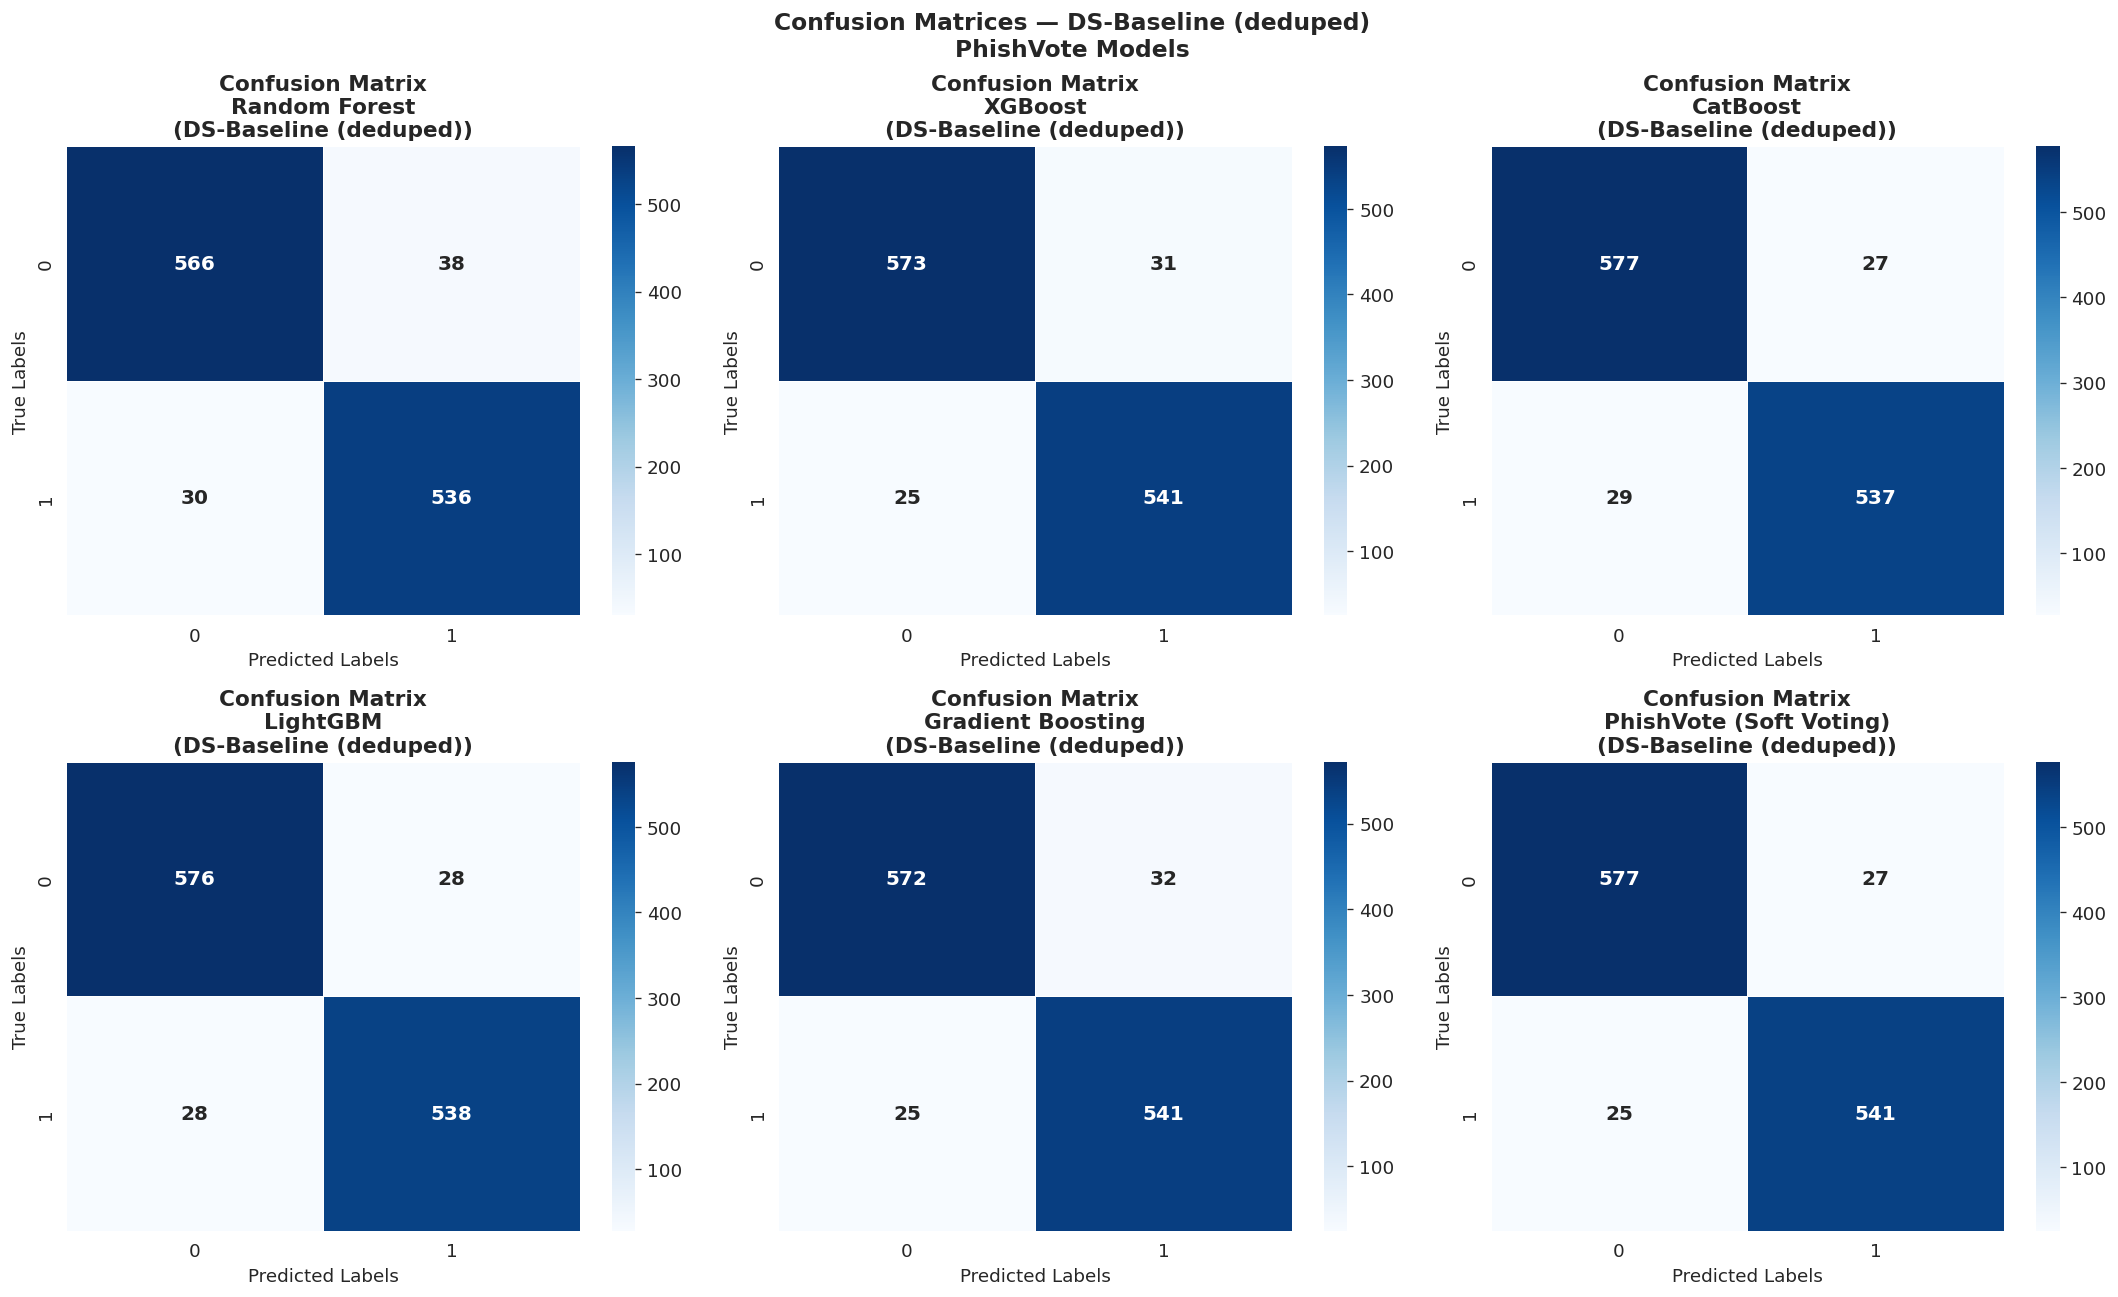

Saved: nb3_cm_baseline.png


In [6]:
# ── Confusion Matrices — DS-Baseline ──

pv_model_order = ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM',
                  'Gradient Boosting', 'PhishVote (Soft Voting)']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, name in zip(axes, pv_model_order):
    plot_confusion_matrix(yt_base, preds_base[name], name, 'DS-Baseline (deduped)', ax)
    if name == 'PhishVote (Soft Voting)':
        ax.set_facecolor('#f0fff4')  # light green highlight for ensemble

fig.suptitle('Confusion Matrices — DS-Baseline (deduped)\nPhishVote Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb3_cm_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb3_cm_baseline.png')

In [7]:
# ── Classification Reports — DS-Baseline ──

for name in pv_model_order:
    print_classification_report(yt_base, preds_base[name], name, 'DS-Baseline (deduped)')


--- Random Forest | DS-Baseline (deduped) ---
                precision    recall  f1-score   support

0 (legitimate)       0.95      0.94      0.94       604
  1 (phishing)       0.93      0.95      0.94       566

      accuracy                           0.94      1170
     macro avg       0.94      0.94      0.94      1170
  weighted avg       0.94      0.94      0.94      1170


--- XGBoost | DS-Baseline (deduped) ---
                precision    recall  f1-score   support

0 (legitimate)       0.96      0.95      0.95       604
  1 (phishing)       0.95      0.96      0.95       566

      accuracy                           0.95      1170
     macro avg       0.95      0.95      0.95      1170
  weighted avg       0.95      0.95      0.95      1170


--- CatBoost | DS-Baseline (deduped) ---
                precision    recall  f1-score   support

0 (legitimate)       0.95      0.96      0.95       604
  1 (phishing)       0.95      0.95      0.95       566

      accuracy        

In [8]:
# ── Accuracy Table — DS-Baseline (mirrors Table I format) ──

print('\nTable — DS-Baseline (deduped):')
print(f'{"Model":<30} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
print('-' * 72)
for _, row in res_base.iterrows():
    print(f'{row["Model"]:<30} {row["Accuracy"]:>9.2f}%'
          f' {row["Precision"]:>10.2f}%'
          f' {row["Recall"]:>8.2f}%'
          f' {row["F1"]:>8.2f}%')


Table — DS-Baseline (deduped):
Model                            Accuracy   Precision    Recall        F1
------------------------------------------------------------------------
Random Forest                      94.19%      93.38%    94.70%    94.04%
XGBoost                            95.21%      94.58%    95.58%    95.08%
CatBoost                           95.21%      95.21%    94.88%    95.04%
LightGBM                           95.21%      95.05%    95.05%    95.05%
Gradient Boosting                  95.13%      94.42%    95.58%    95.00%
PhishVote (Soft Voting)            95.56%      95.25%    95.58%    95.41%


In [9]:
# ==========================================
# 6. RUN — DS01 LEGITPHISH 2025
# ==========================================

res_ds01, preds_ds01, yt_ds01, trained_ds01, _ = run_phishvote(
    df_ds01_d, 'DS01 LegitPhish 2025'
)


  PhishVote — DS01 LegitPhish 2025
  Rows (deduped): 31,808  |  Legitimate (0): 7,059  |  Phishing (1): 24,749
  Train: 25,446  |  Test: 6,362
  Test class 0: 1,412  |  Test class 1: 4,950
  SMOTE applied (imbalance=0.29) → train: 39,598 rows


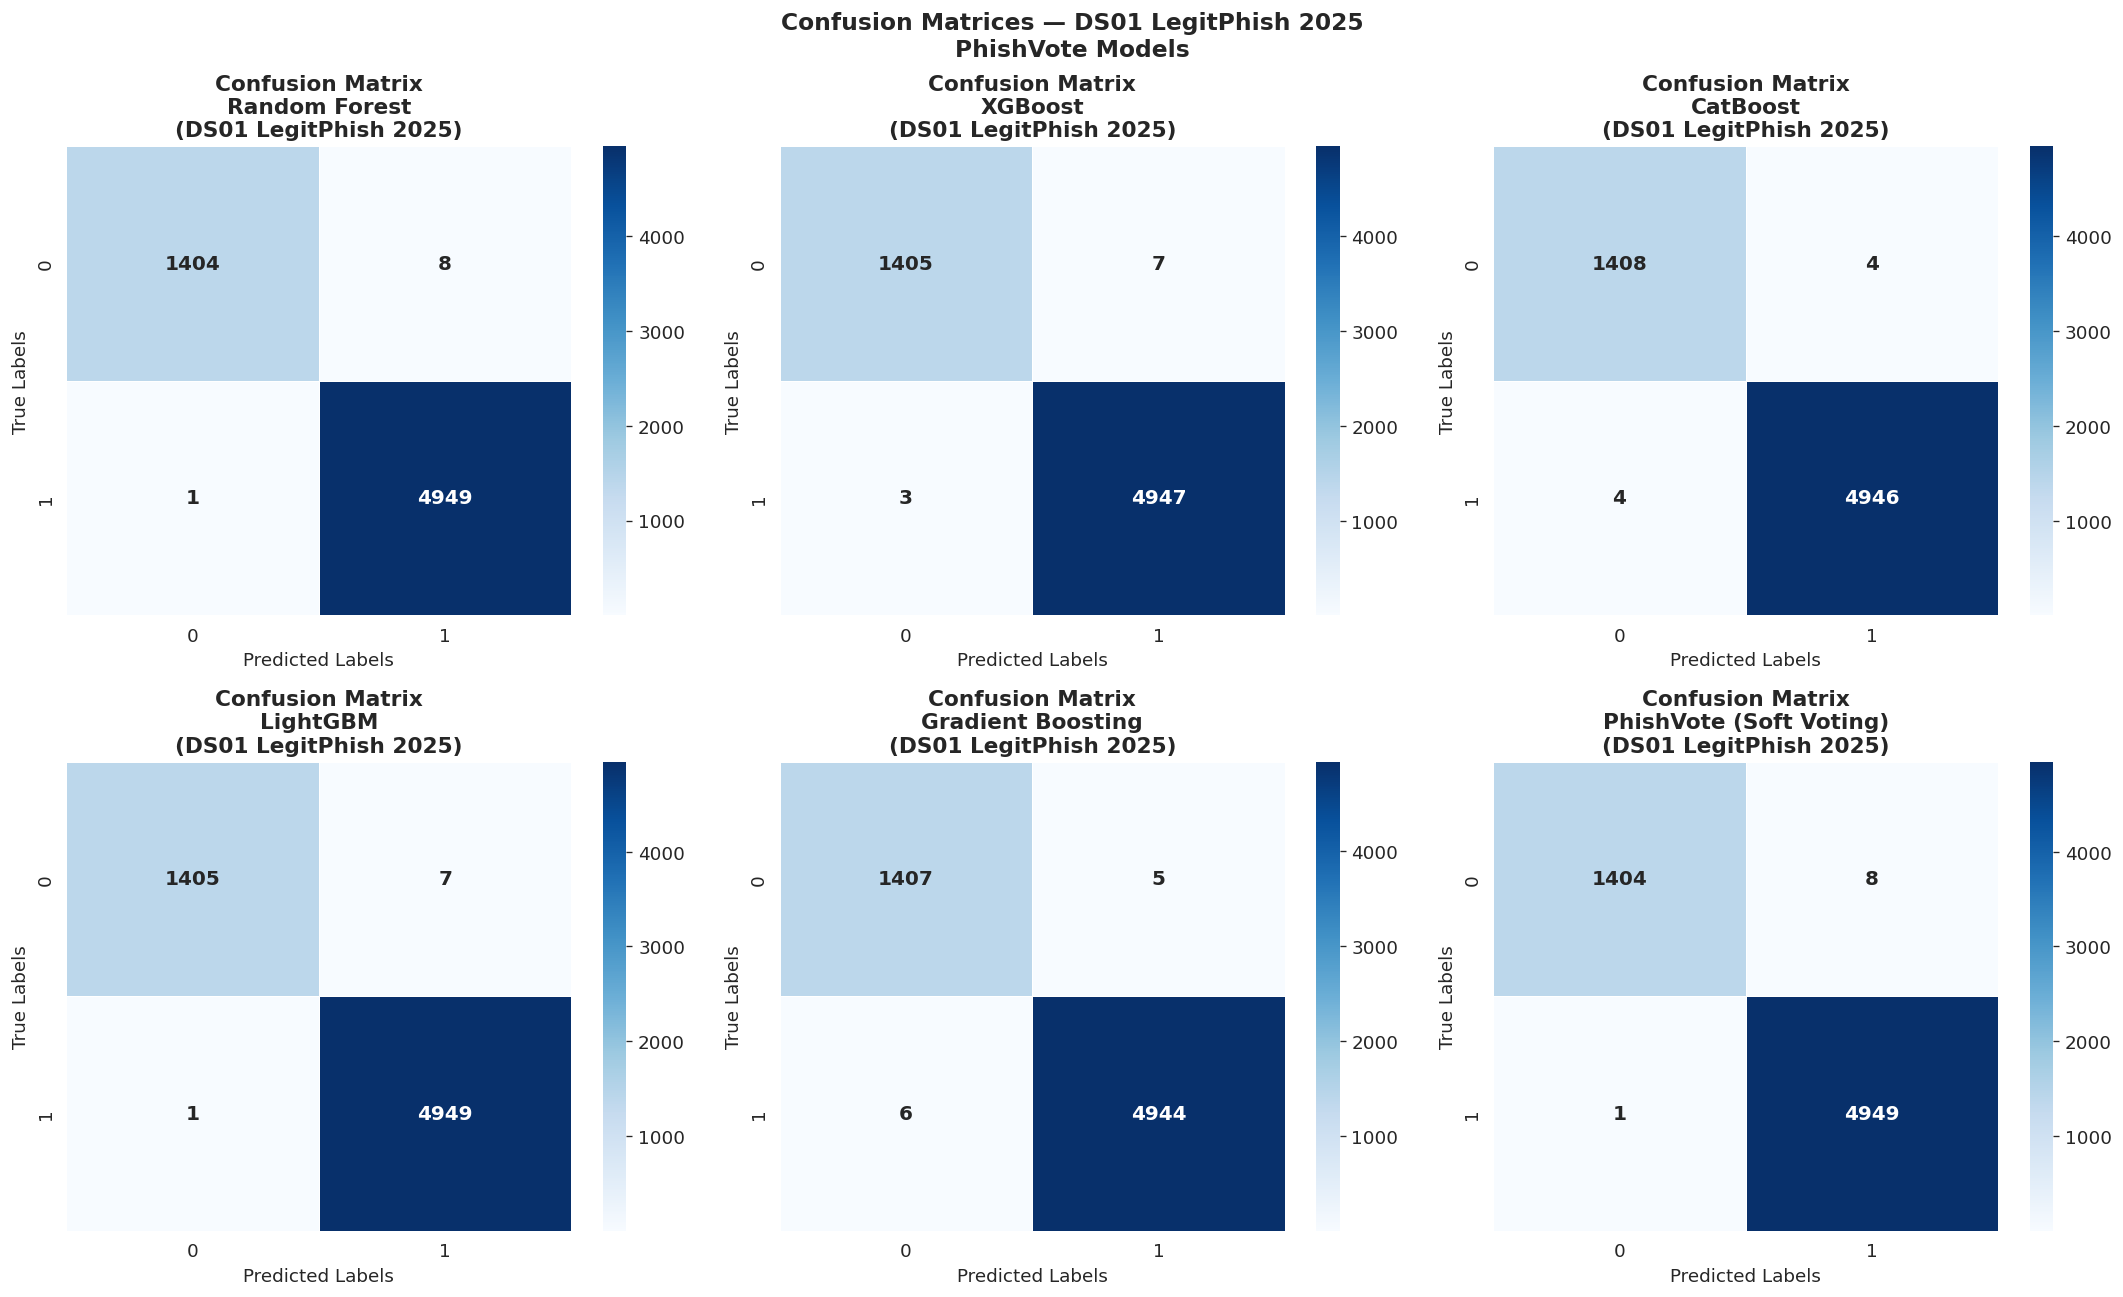

Saved: nb3_cm_ds01.png


In [10]:
# ── Confusion Matrices — DS01 ──

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, name in zip(axes, pv_model_order):
    plot_confusion_matrix(yt_ds01, preds_ds01[name], name, 'DS01 LegitPhish 2025', ax)
    if name == 'PhishVote (Soft Voting)':
        ax.set_facecolor('#f0fff4')

fig.suptitle('Confusion Matrices — DS01 LegitPhish 2025\nPhishVote Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb3_cm_ds01.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb3_cm_ds01.png')

In [11]:
# ── Classification Reports — DS01 ──

for name in pv_model_order:
    print_classification_report(yt_ds01, preds_ds01[name], name, 'DS01 LegitPhish 2025')


--- Random Forest | DS01 LegitPhish 2025 ---
                precision    recall  f1-score   support

0 (legitimate)       1.00      0.99      1.00      1412
  1 (phishing)       1.00      1.00      1.00      4950

      accuracy                           1.00      6362
     macro avg       1.00      1.00      1.00      6362
  weighted avg       1.00      1.00      1.00      6362


--- XGBoost | DS01 LegitPhish 2025 ---
                precision    recall  f1-score   support

0 (legitimate)       1.00      1.00      1.00      1412
  1 (phishing)       1.00      1.00      1.00      4950

      accuracy                           1.00      6362
     macro avg       1.00      1.00      1.00      6362
  weighted avg       1.00      1.00      1.00      6362


--- CatBoost | DS01 LegitPhish 2025 ---
                precision    recall  f1-score   support

0 (legitimate)       1.00      1.00      1.00      1412
  1 (phishing)       1.00      1.00      1.00      4950

      accuracy           

In [12]:
# ── Accuracy Table — DS01 ──

print('\nTable — DS01 LegitPhish 2025:')
print(f'{"Model":<30} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
print('-' * 72)
for _, row in res_ds01.iterrows():
    print(f'{row["Model"]:<30} {row["Accuracy"]:>9.2f}%'
          f' {row["Precision"]:>10.2f}%'
          f' {row["Recall"]:>8.2f}%'
          f' {row["F1"]:>8.2f}%')


Table — DS01 LegitPhish 2025:
Model                            Accuracy   Precision    Recall        F1
------------------------------------------------------------------------
Random Forest                      99.86%      99.84%    99.98%    99.91%
XGBoost                            99.84%      99.86%    99.94%    99.90%
CatBoost                           99.87%      99.92%    99.92%    99.92%
LightGBM                           99.87%      99.86%    99.98%    99.92%
Gradient Boosting                  99.83%      99.90%    99.88%    99.89%
PhishVote (Soft Voting)            99.86%      99.84%    99.98%    99.91%


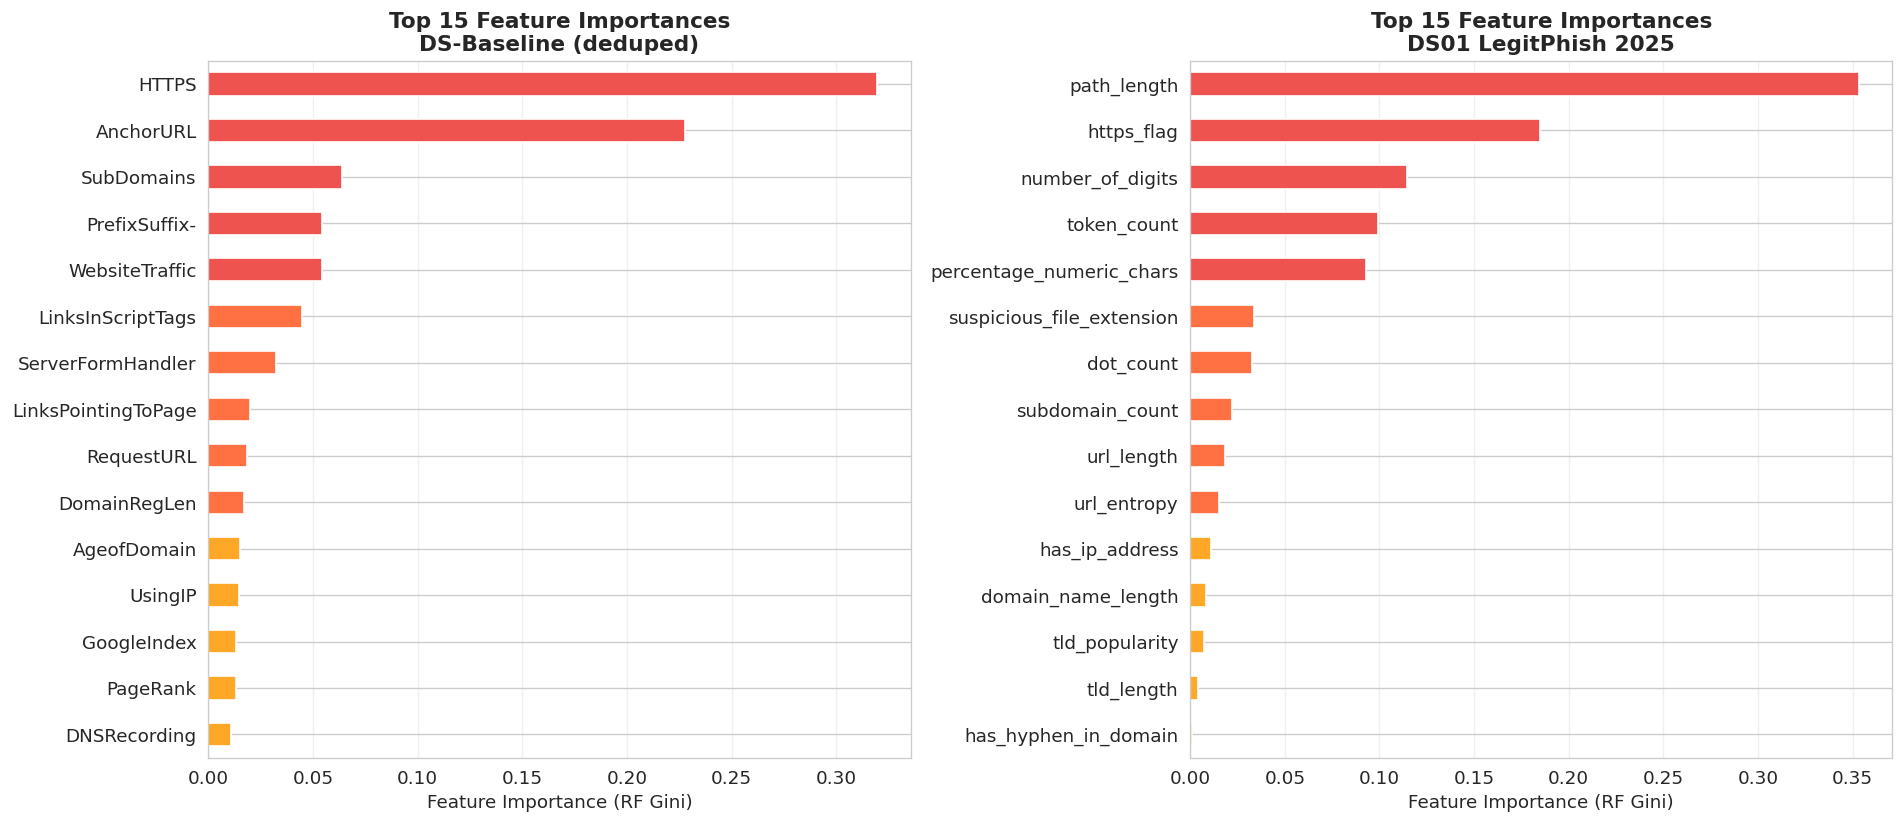

Saved: nb3_feature_importance.png


In [13]:
# ==========================================
# 7. FEATURE IMPORTANCE (Random Forest)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (ds_label, trained, df_clean) in zip(axes, [
    ('DS-Baseline (deduped)', trained_base, df_base_d),
    ('DS01 LegitPhish 2025',  trained_ds01, df_ds01_d)
]):
    rf = trained['Random Forest']
    feat_names   = df_clean.drop(columns=['label']).columns.tolist()
    importances  = pd.Series(rf.feature_importances_, index=feat_names)
    top15        = importances.nlargest(15).sort_values()
    colors_imp   = ['#EF5350' if v >= top15.quantile(0.67) else
                    '#FF7043' if v >= top15.quantile(0.33) else '#FFA726'
                    for v in top15.values]
    top15.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_xlabel('Feature Importance (RF Gini)')
    ax.set_title(f'Top 15 Feature Importances\n{ds_label}', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('nb3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb3_feature_importance.png')

In [14]:
# ==========================================
# 8. MASTER COMPARISON TABLE
# ==========================================
# PhishVote ensemble vs Saeed (2025) ensemble — all datasets

df_all = pd.concat([res_base, res_ds01], ignore_index=True)

# Saeed (2025) published numbers (Table I of their paper)
saeed_pub = {
    ('DS-Baseline', 'Logistic Regression'):  (93.31, None, None, None),
    ('DS-Baseline', 'Gradient Boosting'):    (94.93, None, None, None),
    ('DS-Baseline', 'KNN'):                  (94.35, None, None, None),
    ('DS-Baseline', 'Hard Voting Ensemble'): (95.02, 95.0, 95.0, 95.0),
}

print('\n' + '='*72)
print('📌 MASTER COMPARISON: PhishVote vs Saeed (2025)')
print('='*72)

for ds_label in ['DS-Baseline (deduped)', 'DS01 LegitPhish 2025']:
    print(f'\n🔹 {ds_label}')
    print(f'  {"Model":<30} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
    print('  ' + '-'*70)

    grp = df_all[df_all['Dataset'] == ds_label]
    for _, row in grp.iterrows():
        marker = ' ◀ ENSEMBLE' if row['Model'] == 'PhishVote (Soft Voting)' else ''
        print(f'  {row["Model"]:<30} {row["Accuracy"]:>9.2f}%'
              f' {row["Precision"]:>10.2f}%'
              f' {row["Recall"]:>8.2f}%'
              f' {row["F1"]:>8.2f}%{marker}')

    if ds_label == 'DS-Baseline (deduped)':
        print(f'\n  -- Saeed (2025) published (raw, for reference) --')
        for model, (acc, prec, rec, f1) in saeed_pub.items():
            ds, m = model
            acc_s  = f'{acc:.2f}%'
            prec_s = f'{prec:.2f}%' if prec else 'N/A'
            rec_s  = f'{rec:.2f}%'  if rec  else 'N/A'
            f1_s   = f'{f1:.2f}%'   if f1   else 'N/A'
            print(f'  {m:<30} {acc_s:>10} {prec_s:>11} {rec_s:>9} {f1_s:>9}')

print()
print('NOTE: Saeed (2025) raw numbers are on the undeduped DS-Baseline (inflated by ~3.5pp).')
print('      PhishVote runs on deduped data — fair and honest comparison.')


📌 MASTER COMPARISON: PhishVote vs Saeed (2025)

🔹 DS-Baseline (deduped)
  Model                            Accuracy   Precision    Recall        F1
  ----------------------------------------------------------------------
  Random Forest                      94.19%      93.38%    94.70%    94.04%
  XGBoost                            95.21%      94.58%    95.58%    95.08%
  CatBoost                           95.21%      95.21%    94.88%    95.04%
  LightGBM                           95.21%      95.05%    95.05%    95.05%
  Gradient Boosting                  95.13%      94.42%    95.58%    95.00%
  PhishVote (Soft Voting)            95.56%      95.25%    95.58%    95.41% ◀ ENSEMBLE

  -- Saeed (2025) published (raw, for reference) --
  Logistic Regression                93.31%         N/A       N/A       N/A
  Gradient Boosting                  94.93%         N/A       N/A       N/A
  KNN                                94.35%         N/A       N/A       N/A
  Hard Voting Ensemble        

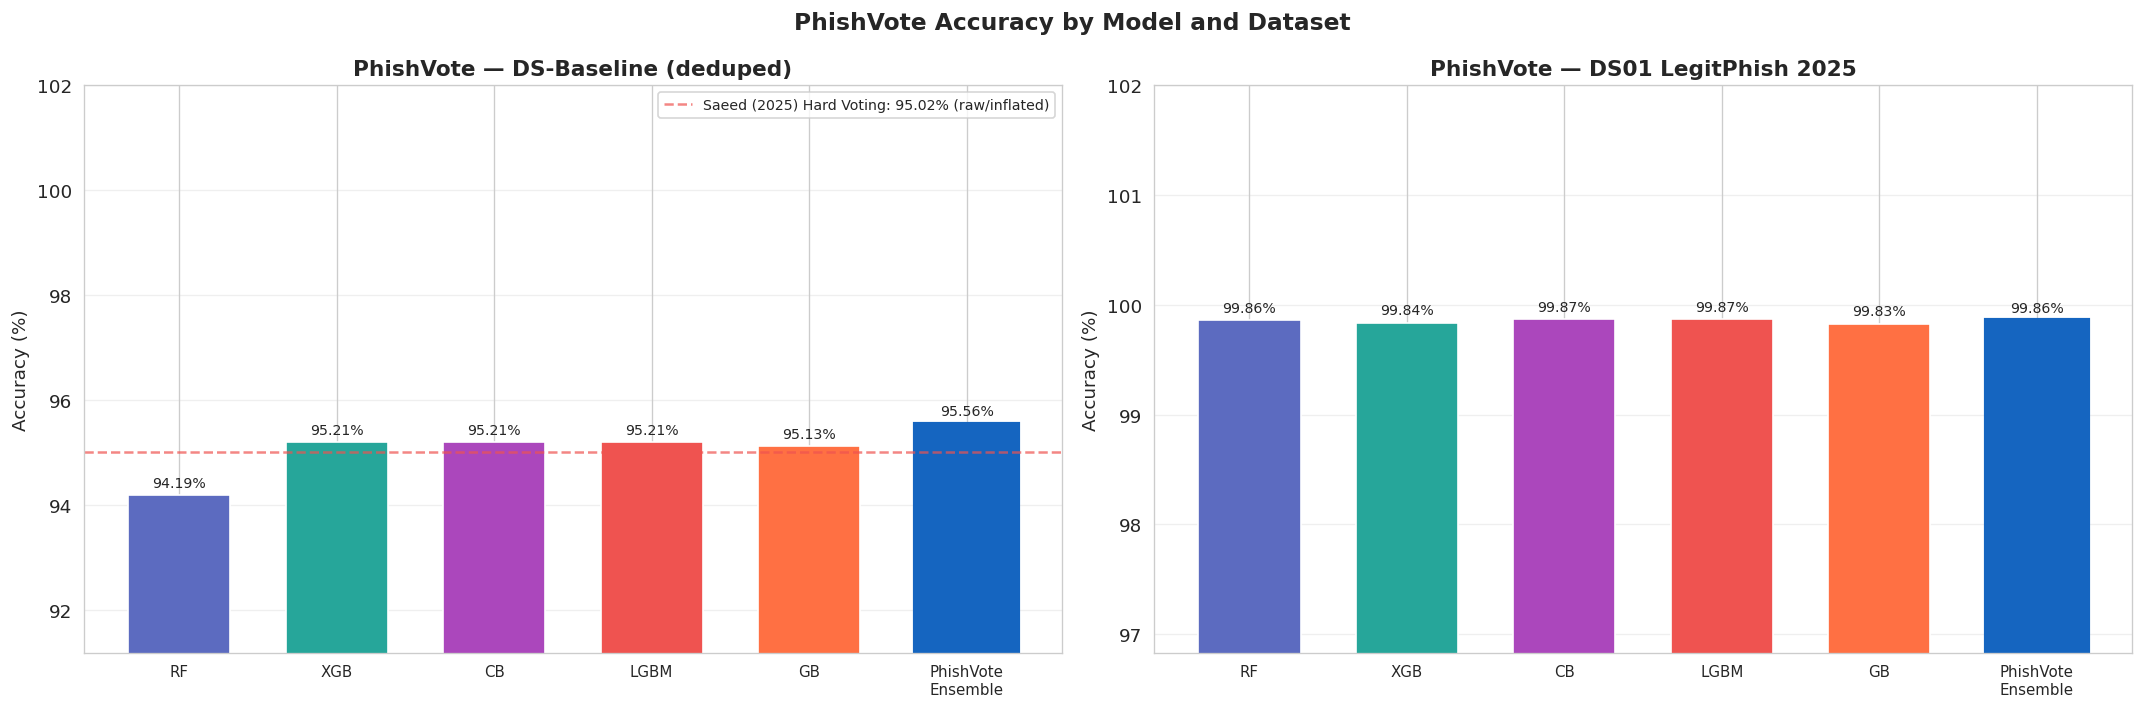

Saved: nb3_accuracy_chart.png


In [15]:
# ==========================================
# 9. FINAL COMPARISON BAR CHART
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pal = ['#5C6BC0','#26A69A','#AB47BC','#EF5350','#FF7043','#1565C0']

for ax, (ds_label, res) in zip(axes, [
    ('DS-Baseline (deduped)', res_base),
    ('DS01 LegitPhish 2025',  res_ds01)
]):
    models_plot = pv_model_order
    accs = res.set_index('Model').reindex(models_plot)['Accuracy'].values
    bars = ax.bar(range(len(models_plot)), accs, color=pal, edgecolor='white', width=0.65)
    ax.bar_label(bars, fmt='%.2f%%', fontsize=8.5, padding=3)

    # Add Saeed ensemble line on DS-Baseline panel for reference
    if 'DS-Baseline' in ds_label:
        ax.axhline(95.02, linestyle='--', color='#EF5350', linewidth=1.5, alpha=0.7,
                   label='Saeed (2025) Hard Voting: 95.02% (raw/inflated)')
        ax.legend(fontsize=8.5)

    ax.set_xticks(range(len(models_plot)))
    ax.set_xticklabels(['RF','XGB','CB','LGBM','GB','PhishVote\nEnsemble'], fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'PhishVote — {ds_label}', fontweight='bold')
    ax.set_ylim(min(accs[~np.isnan(accs)]) - 3, 102)
    ax.grid(axis='y', alpha=0.3)
    bars[-1].set_edgecolor('#1565C0')
    bars[-1].set_linewidth(2.5)

plt.suptitle('PhishVote Accuracy by Model and Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb3_accuracy_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb3_accuracy_chart.png')